# 0. Setting up
This block will install `ml4fmri` package and download some sample fMRI data for tests.

In [1]:
# Install ml4fmri
! pip install ml4fmri -q
! pip show ml4fmri
# clone its repository (to get example data loading scripts)
! git clone --branch ml4fmri https://github.com/neuroneural/meanMLP.git # repo is cloned to get data loading script. It is not necessary for ml4fmri.
! pip install --upgrade requests h5py -q # install requests and h5py to ensure it's installed and up-to-date (required to download and load example data)
! python meanMLP/scripts/download_datasets.py

# setting log config to show INFO channel. Google colab shows only warnings, ml4fmri logs its progress in INFO stream.
import sys, logging
import subprocess

logging.basicConfig(
    level=logging.INFO,                              # show INFO+
    format="%(asctime)s | %(levelname)s | %(name)s: %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)],    # print to cell output
    force=True,                                      # reconfigure in notebooks
)

Name: ml4fmri
Version: 1.0.8.dev0+g73d8dace1.d20260729
Summary: Machine learning models for fMRI classification
Home-page: https://github.com/neuroneural/meanMLP/tree/ml4fmri
Author: Pavel Popov
Author-email: 
License: MIT
Location: /Users/ppopov1/miniconda3/envs/circrna/lib/python3.12/site-packages
Editable project location: /Users/ppopov1/ml4fmri
Requires: matplotlib, numpy, pandas, scikit-learn, torch
Required-by: 
Cloning into 'meanMLP'...
remote: Enumerating objects: 1357, done.
remote: Counting objects: 100% (442/442), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 1357 (delta 306), reused 368 (delta 259), pack-reused 915 (from 1)
Receiving objects: 100% (1357/1357), 8.43 MiB | 9.26 MiB/s, done.
Resolving deltas: 100% (875/875), done.


In [2]:
# GET EXAMPLE fMRI DATA: ABIDE dataset with 569 subjects
import numpy as np

from meanMLP.scripts.abide import load_data as load_abide
from meanMLP.scripts.cobre import load_data as load_cobre
DATA, LABELS = load_abide(
    dataset_path = "./meanMLP/assets/data/abide/ABIDE1_AllData.h5",
    indices_path = "./meanMLP/assets/data/ICA_correct_order.csv",
    labels_path = "./meanMLP/assets/data/abide/labels_ABIDE1.csv",
)
print(f"Data shape: {DATA.shape}, Labels shape: {LABELS.shape}")
print(f"Unique labels: {np.unique(LABELS)}, Counts: {np.bincount(LABELS)}")

Data shape: (569, 140, 53), Labels shape: (569,)
Unique labels: [0 1], Counts: [255 314]


# 1. Run cross-validation classification experiments with `ml4fmri.cvbench`

`ml4fmri` has a function `cvbench` that runs cross-validation experiments with the models in the package on the provided data.

Benchmarking all available models on the 569 subjects from ABIDE takes about an hour on Google Colab T4 GPU.

Results are saved to disk in the `save_dir` folder (default is `cvbench_{timestamp}`), and also returned as a `Report` object for easy plotting and analysis.

In [3]:
from ml4fmri import cvbench # runs CV classification experiments with different fMRI models on your data
# EXPECTED DATA SHAPE: data (SUBJECTS, TIME, FEATURES), labels (SUBJECTS)
report = cvbench(DATA,
                 LABELS,
                 models='meanMLP', # (default for GPU) test all models. Other options:
                #  models='lite', # (default for CPU) use only faster models, better for quick tests or if you don't have GPU.
                ###  Lite models include Logistic regression and BNT (2 FNC models), and meanMLP and MILC (2 time series models)
                #  models='ts', # run only time series models
                #  models='fnc', # run only FNC models; FNC matrices are derived from the input time series as Pearson correlation coefficients
                #  models='meanMLP', # run only meanMLP (or any other model); see description on https://pypi.org/project/ml4fmri/ for more info on available models
                #  models=['LR', 'meanMLP'], # run only Logistic regression and meanMLP models
                #
                #  n_folds=5, # Number of CV folds; 10 is default
                #  epochs=200, # max number of epochs used for training; default is 200
                #  patience=30, # early stop the model training if validation loss doesn't improve for `patience` epochs
                 )
# report object contains the results of experiments. We will inspect it in the next cells

19:12:05 | INFO | cvbench: Got DATA in shape (569, 140, 53) and LABELS in shape (569,)
19:12:05 | INFO | cvbench: Unique labels: [0 1], Counts: [255 314]
19:12:05 | INFO | cvbench: Assuming that (#Samples = 569, Time = 140, #Features = 53)
19:12:05 | INFO | cvbench: Using device: mps
19:12:05 | INFO | cvbench: Running models: ['meanMLP']
19:12:05 | INFO | cvbench: Saving results to: /Users/ppopov1/ml4fmri/scripts/cvbench_20260729_191205
19:12:05 | INFO | cvbench: Training model: meanMLP
19:12:10 | INFO | cvbench.meanMLP: Fold 01/10: Train/Val/Test AUC 0.977/0.749/0.849: Time elapsed 4.93 s
19:12:12 | INFO | cvbench.meanMLP: Fold 02/10: Train/Val/Test AUC 0.929/0.736/0.636: Time elapsed 2.07 s
19:12:15 | INFO | cvbench.meanMLP: Fold 03/10: Train/Val/Test AUC 0.968/0.786/0.694: Time elapsed 2.28 s
19:12:17 | INFO | cvbench.meanMLP: Fold 04/10: Train/Val/Test AUC 0.974/0.792/0.756: Time elapsed 2.42 s
19:12:20 | INFO | cvbench.meanMLP: Fold 05/10: Train/Val/Test AUC 0.918/0.741/0.773: Tim

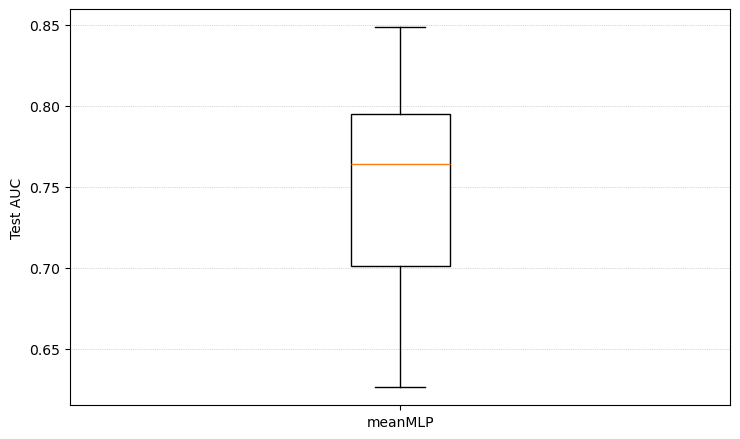

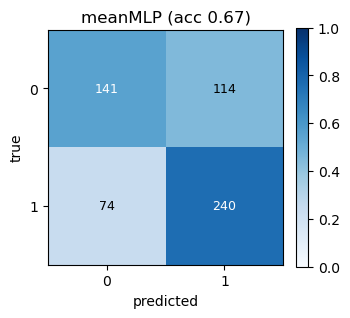

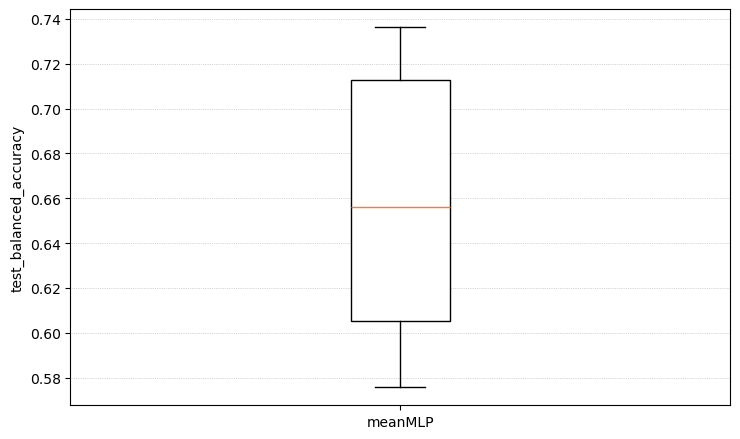

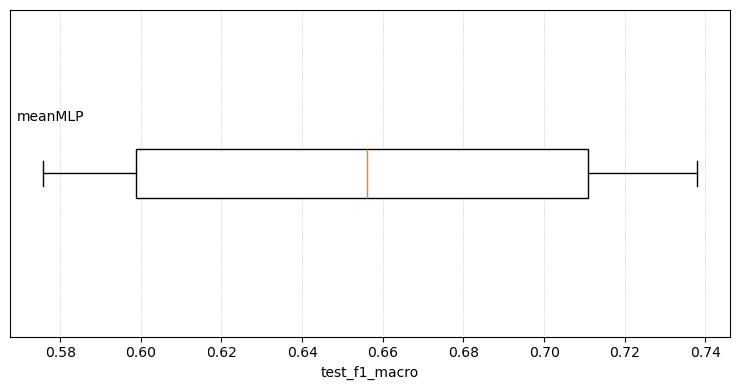

In [8]:
# plot test scores (default is AUC). Other metrics are available too, you'll see them in the next cell
# ///-box models work with FNC data, plain-box models work with time series.
report.plot_scores() # default AUC
report.plot_confusion()
report.plot_scores(metric="test_balanced_accuracy")
report.plot_scores_h(metric="test_f1_macro")

In [ ]:
# extract report dataframes

test_df = report.get_test_dataframe() # returns dataframe with test metrics:
# classification metrics and loss on the test data and training time per fold for each model.
# Useful for model comparison.

train_df = report.get_train_dataframe() # returns dataframe with training logs:
# losses and classification metrics on the training and validation data per fold for each model.
# Useful for training inspection.
print(f"Some of the metrics available for plotting in report.plot_scores() and report.plot_scores_h(), pick the nonsense ones at your own risk:\n {test_df.columns}")

meta_df = report.get_meta() # dictionary with metadata about the training process:
# keys: 'status', 'ml4fmri_version', 'created', 'finished', 'elapsed_seconds', 'models', 'custom_models',
#       'data' (n_samples, n_timepoints, input_size, n_classes, class_counts, sample_ids_provided),
#       'cv' (n_folds, val_ratio), 'seeds' (cv_seed, val_seed, init_seed),
#       'training' (epochs, lr, patience, device), 'save_checkpoints'
# per-fold train/val/test indices are no longer in meta -- they're written to
# <save_dir>/fold_records/fold_XX/indices.json instead

preds_df = report.get_predictions_dataframe() # raw test-fold probabilities per sample, one row per (model, fold, sample)

Some of the metrics available for plotting in report.plot_scores() and report.plot_scores_h(), pick the nonsense ones at your own risk:
 Index(['model', 'fold', 'test_CE_loss', 'test_loss', 'test_accuracy',
       'test_balanced_accuracy', 'test_auc', 'test_f1_macro',
       'test_cm_true0_pred0', 'test_cm_true0_pred1', 'test_cm_true1_pred0',
       'test_cm_true1_pred1', 'train_time', 'n_params'],
      dtype='str')


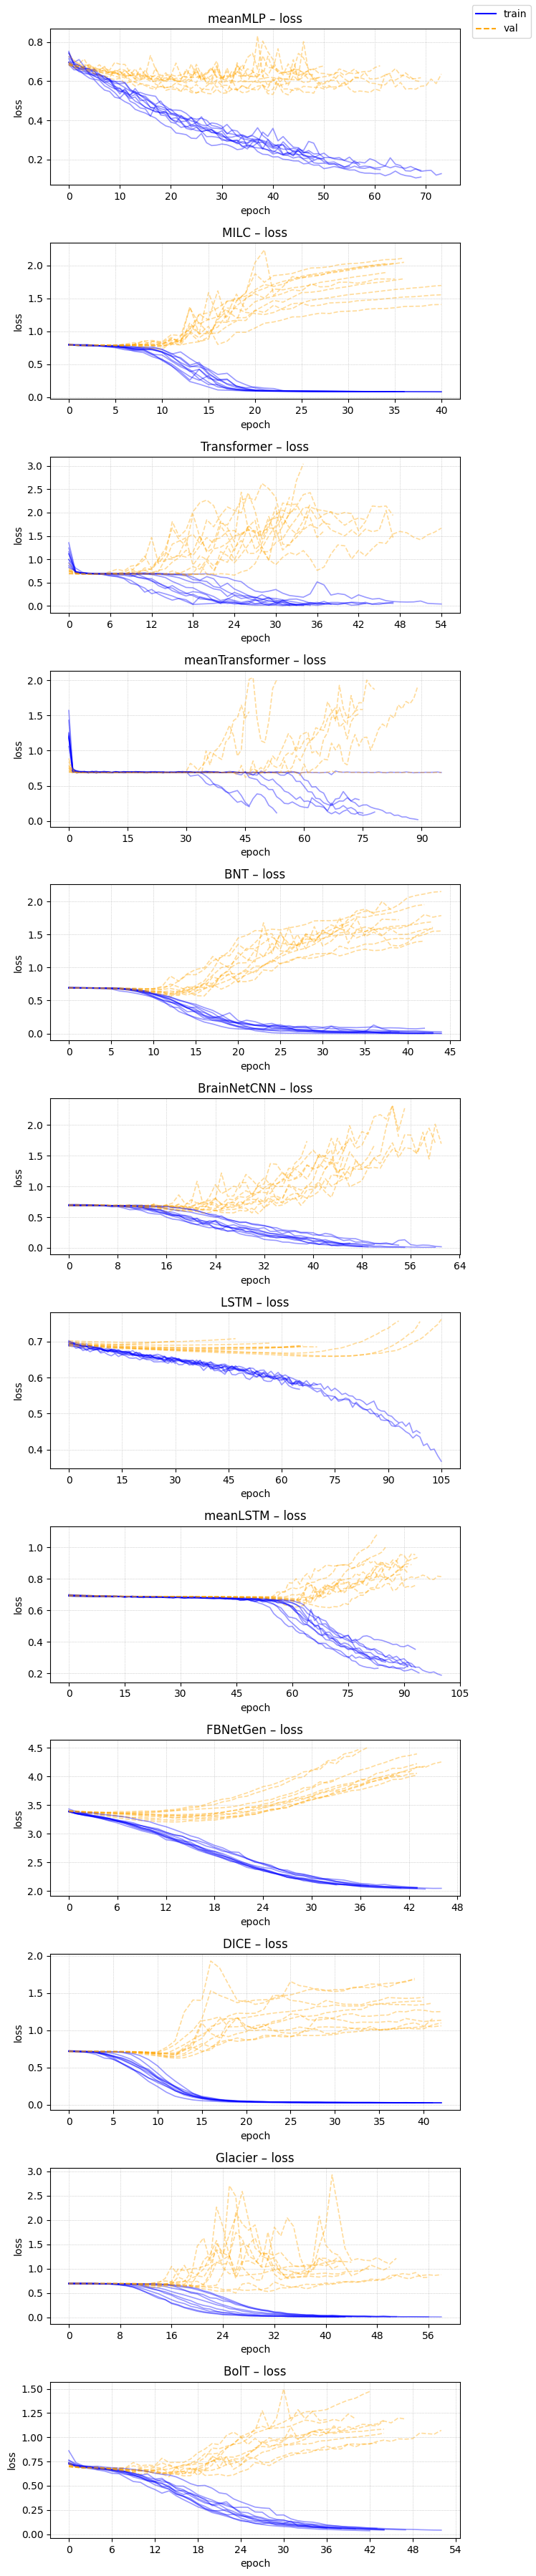

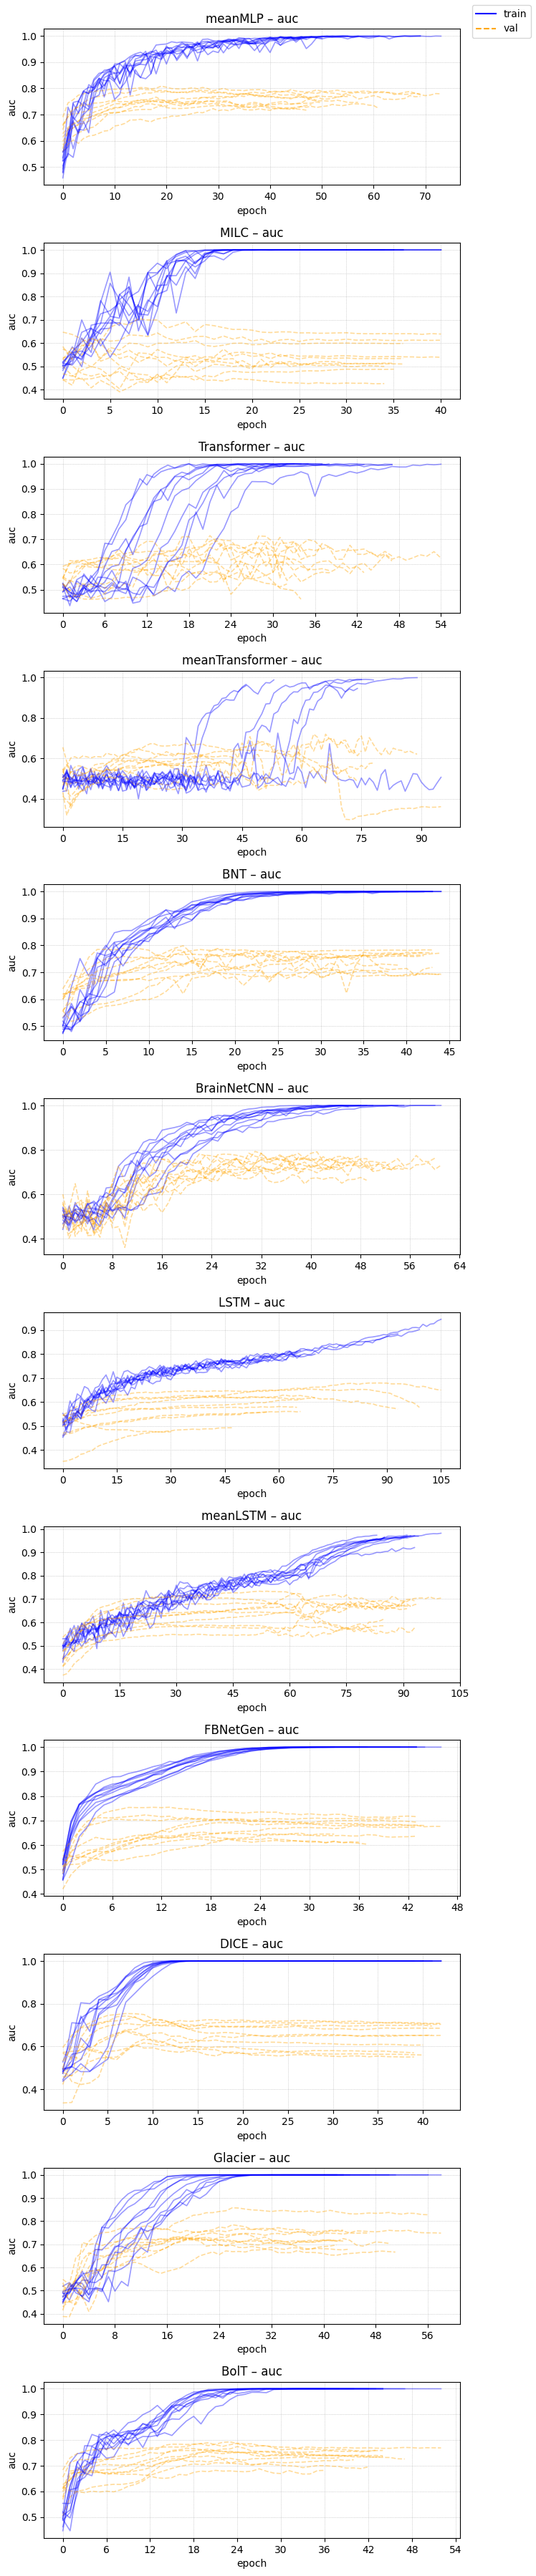

(None, None)

In [ ]:
# plot training curves: allows you to inspect how models trained, if there were any anomalies
report.plot_training_curves()

## 1.1. Add custom models to cvbench
`cvbench` has an option to run **your custom models** that has implemented the `train_model` and `prepare_dataloader` API methods, defined like in the rest of the models. It also needs to be initializable with only 2 required arguments: `input_size` (feature size in time series, or side of an FNC matrix) and `output_size` (expects `n_classes`), and return train and test logs after training.

In [10]:
# let's redefine LSTM: make it use all LSTM outputs for classification, and also tell it to predict future signals

import torch
from torch import nn

from torch.nn.functional import cross_entropy, mse_loss

from ml4fmri.models.helper_functions import basic_handle_batch, basic_dataloader, basic_Adam_optimizer, BasicTrainer

class LSTM(nn.Module):
    """
    TIME SERIES MODEL

    Expected input shape: [batch_size, time_length, input_feature_size].
    Output: [batch_size, n_classes]
    """

    def __init__(
            self,
            input_size: int,
            output_size: int,
            hidden_size: int = 210,
            num_layers: int = 1,
            bidirectional: bool = False,
            dropout: float = 0.5,
            lr: float = 4e-5,
    ):
        """
        Initialize LSTM model.
        Args:
            input_size (int): Size of the vector at each time step in the input time series. \
                Common to all models, for FNC models it is the number of nodes (width or length) in the FNC matrix.
            output_size (int): Number of classes for classification. \
                Common to all models.
            hidden_size (int, hyperparameter): LSTM hidden size. Defaults to 210.
            num_layers (int, hyperparameter): Number of LSTM layers. Defaults to 1.
            bidirectional (bool, hyperparameter): Whether to use a bidirectional LSTM. Defaults to True.
            dropout (float, hyperparameter): Dropout rate for classifier. Defaults to 0.5.
            lr (float, hyperparameter): Learning rate for the optimizer. Defaults to 4e-5. \
                Common to all models. Isn't used by the model per se, presented as a reference LR from the paper.
        """
        super().__init__()
        self.lr = lr  # learning rate used in the paper. Defined like this in every model for reference.

        self.bidirectional = bidirectional
        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
        )

        lstm_output_size = 2 * hidden_size if bidirectional else hidden_size

        self.predictor = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(
                lstm_output_size,
                lstm_output_size,
            ),
            nn.ReLU(),
            nn.Linear(
                lstm_output_size,
                input_size,
            ),
        )

        self.clf = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(
                lstm_output_size,
                output_size,
            ),
        )

    def forward(self, x):
        lstm_output, _ = self.lstm(x)

        if self.bidirectional:
            out_forward = lstm_output[:, -1, : self.hidden_size]
            out_reverse = lstm_output[:, 0, self.hidden_size :]
            lstm_output_clf = torch.cat((out_forward, out_reverse), 1)
        else:
            lstm_output_clf = lstm_output[:, -1, :]

        preds = self.predictor(lstm_output[:, :-1, :])
        origs = x[:, 1:, :]

        ts_logits = self.clf(lstm_output)
        logits = ts_logits.mean(axis=1)

        return logits, {"logits": logits, "preds": preds, "origs": origs, "ts_logits": ts_logits}

    #### Helper functions for model training and evaluation ####

    def compute_loss(self, loss_load, targets):
        """
        Standard loss computation routine for models.
        Args:
            loss_load (dict): Forward's second output for the batch.
            targets (torch.Tensor): True labels for the batch.

        Returns
        -------
        loss : Tensor
            Loss for backpropagation.
        logs : dict
            Dictionary containing the loss components for logs.
        """

        ce_loss = cross_entropy(loss_load["logits"], targets)
        pred_loss = mse_loss(loss_load["preds"], loss_load["origs"])

        loss = ce_loss + pred_loss

        return loss, {"CE_loss": float(ce_loss.detach().cpu().item()), "Pred_loss": float(pred_loss.detach().cpu().item())}

    def handle_batch(self, batch):
        """
        Standard batch handling routine for models.
        Returns loss for backprop and a dictionary of classification metrics and losses for logs.

        Args:
            batch (tuple): A batch containing the time series data and labels as a tuple.
        Returns
        -------
        loss : Tensor
            Loss for backpropagation.
        batch_log : dict
            Dictionary of classification metrics and losses for logs.
        """

        loss, batch_log = basic_handle_batch(self, batch)
        return loss, batch_log

    def get_optimizer(self, lr=None):
        """
        Standard optimizer getter routine for models.
        """
        if lr is None:
            lr = self.lr
        return basic_Adam_optimizer(self, lr)

    @staticmethod
    def prepare_dataloader(data,
                           labels,
                           batch_size: int = 64,
                           shuffle: bool = True):
        """
        Returns torch DataLoader that produces appropriate batches for the model (can pass to `handle_batch`)
        Args:
            data (array-like): Time series data of shape (B, T, D).
            labels (array-like): Class labels for the data.
            batch_size (int, optional): Batch size for the DataLoader. Defaults to 64.
            shuffle (bool, optional): Whether to shuffle batching in the DataLoader. Defaults to True.

        Returns:
            DataLoader: A PyTorch DataLoader generating the batches of time series data and labels.
        """
        return basic_dataloader(data,
                                labels,
                                type="TS",
                                batch_size=batch_size,
                                shuffle=shuffle)

    def train_model(self,
              train_loader,
              val_loader,
              test_loader,
              epochs: int = 200,
              lr: float = None,
              device: str = None,
              patience: int = 30,
        ):
        """
        Standard model training routine.
        Args:
            train_loader (DataLoader): DataLoader for the training set. Used for training.
            val_loader (DataLoader): DataLoader for the validation set. Used during training to find most generalizable model.
            test_loader (DataLoader): DataLoader for the test set.
            epochs (int, optional): Number of training epochs. Defaults to 200.
            lr (float, optional): Optimizer learning rate (default: use model's self.lr).
            device (str, optional): Device to train the model on: "cuda", "mps", or "cpu". Default: auto-detect (cuda -> mps -> cpu).
            patience (int, optional): Early stopping patience (in epochs). Defaults to 30.
        Returns
        -------
        (train_log, test_log, predictions_log)
            Training log, test log, and raw test-fold predictions, all as DataFrames.
        """

        trainer = BasicTrainer(
            model=self,
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            epochs=epochs,
            lr=lr,
            device=device,
            patience=patience,
        )

        return trainer.run()


19:15:38 | INFO | cvbench: Got DATA in shape (569, 140, 53) and LABELS in shape (569,)
19:15:38 | INFO | cvbench: Unique labels: [0 1], Counts: [255 314]
19:15:38 | INFO | cvbench: Assuming that (#Samples = 569, Time = 140, #Features = 53)
19:15:38 | INFO | cvbench: Using device: mps
19:15:38 | WARNING | cvbench: Custom model 'LSTM' has the same name as one of the bundled models; it will replace it


19:15:38 | INFO | cvbench: Running models: ['LSTM', 'meanMLP']
19:15:38 | INFO | cvbench: Saving results to: /Users/ppopov1/ml4fmri/scripts/cvbench_20260729_191538
19:15:38 | INFO | cvbench: Training model: LSTM
19:15:55 | INFO | cvbench.LSTM: Fold 01/05: Train/Val/Test AUC 0.819/0.689/0.616: Time elapsed 16.33 s
19:16:11 | INFO | cvbench.LSTM: Fold 02/05: Train/Val/Test AUC 0.882/0.728/0.574: Time elapsed 16.00 s
19:16:25 | INFO | cvbench.LSTM: Fold 03/05: Train/Val/Test AUC 0.827/0.716/0.621: Time elapsed 14.50 s
19:16:42 | INFO | cvbench.LSTM: Fold 04/05: Train/Val/Test AUC 0.891/0.721/0.665: Time elapsed 17.13 s
19:16:58 | INFO | cvbench.LSTM: Fold 05/05: Train/Val/Test AUC 0.845/0.607/0.662: Time elapsed 16.04 s
19:16:58 | INFO | cvbench: Training model: meanMLP
19:17:01 | INFO | cvbench.meanMLP: Fold 01/05: Train/Val/Test AUC 0.966/0.774/0.728: Time elapsed 2.59 s
19:17:03 | INFO | cvbench.meanMLP: Fold 02/05: Train/Val/Test AUC 0.971/0.764/0.717: Time elapsed 2.55 s
19:17:06 | I

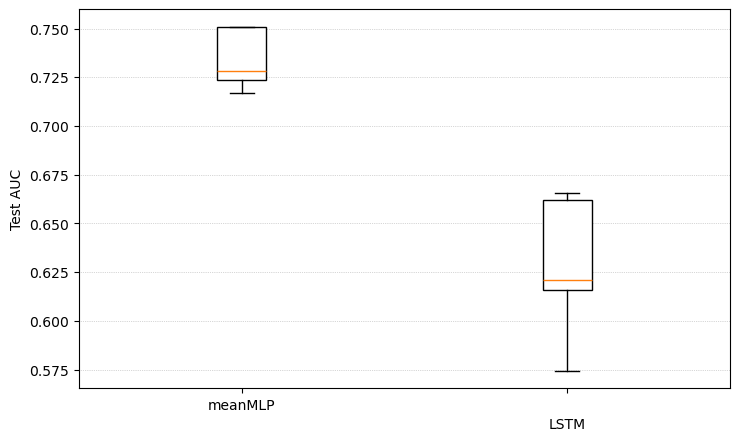

In [11]:
# and now let's plug it into cvbench
# if the name of the custom models coincides with the implemented models, then the custom model overrides
from ml4fmri import cvbench
report = cvbench(DATA,
                 LABELS,
                 models=["meanMLP", "LSTM"],
                 custom_models=LSTM, # can also be a list of model classes. This LSTM will override LSTM on the line above.
                 n_folds=5)
# report = cvbench(data, labels, models=["meanMLP", "LSTM"], n_folds=5)
report.plot_scores()

# 2. Training models manually
Let's train meanMLP and BNT models on manual splits.
Models have standardazied API for training, so they can be used in your experiment setup with less effort.

Models also offer more API hooks for deeper training integration like batch handling, loss calculation, etc. Check models' source code at `ml4fmri.models` for more details.

Training data shape: (341, 140, 53) (341,)
Validation data shape: (91, 140, 53) (91,)
Test data shape: (137, 140, 53) (137,)
Test logs:
     model  test_CE_loss  test_loss  test_accuracy  test_balanced_accuracy  \
0  meanMLP       0.67897    0.67897       0.620438                0.613977   

   test_auc  test_f1_macro  test_cm_true0_pred0  test_cm_true0_pred1  \
0  0.658604       0.612994                   33                   31   

   test_cm_true1_pred0  test_cm_true1_pred1  train_time  n_params  
0                   21                   52    3.443176      9282  



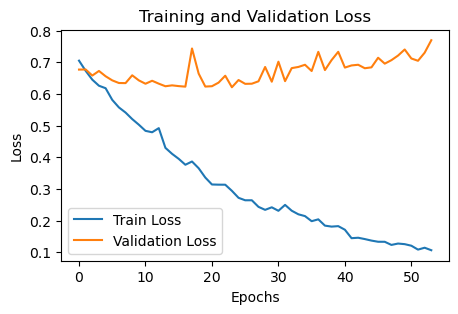

In [12]:
# meanMLP is TIME SERIES MODEL

from ml4fmri.models import meanMLP
from sklearn.model_selection import train_test_split

# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(DATA, LABELS, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.6, random_state=42)
input_size = DATA.shape[2]  # Feature size
n_classes = len(set(LABELS))  # Number of classes

# Print the shapes of the splits
print("Training data shape:", X_train.shape, y_train.shape)
print("Validation data shape:", X_val.shape, y_val.shape)
print("Test data shape:", X_test.shape, y_test.shape)

# prepare dataloaders for meanMLP. meanMLP is time series model, so it will just wrap the input data into pytorch dataloaders
# check the `basic_dataloader` implementation in `ml4fmri/models/helper_functions`
train_dataloader = meanMLP.prepare_dataloader(X_train, y_train, batch_size=32)
val_dataloader = meanMLP.prepare_dataloader(X_val, y_val, batch_size=32)
test_dataloader = meanMLP.prepare_dataloader(X_test, y_test, batch_size=32)

# Train the meanMLP model
model = meanMLP(input_size=input_size, output_size=n_classes)
train_log, test_log, predictions_log = model.train_model(
    train_dataloader,
    val_dataloader,
    test_dataloader,
    epochs=100,
    )

# show test logs
print(f"Test logs:\n{test_log}\n")

# show training loss curves
import matplotlib.pyplot as plt

# Extract train and validation loss from train_log
train_loss = train_log['train_loss'].tolist()
val_loss = train_log['val_loss'].tolist()

# Plot the losses
plt.figure(figsize=(5, 3))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


Training data shape: (341, 140, 53) (341,)
Validation data shape: (91, 140, 53) (91,)
Test data shape: (137, 140, 53) (137,)
Test logs:
  model  test_CE_loss  test_loss  test_accuracy  test_balanced_accuracy  \
0   BNT      0.640612   0.640612       0.671533                0.663848   

   test_auc  test_f1_macro  test_cm_true0_pred0  test_cm_true0_pred1  \
0  0.680865       0.662838                   35                   29   

   test_cm_true1_pred0  test_cm_true1_pred1  train_time  n_params  
0                   16                   57    7.468136    662498  



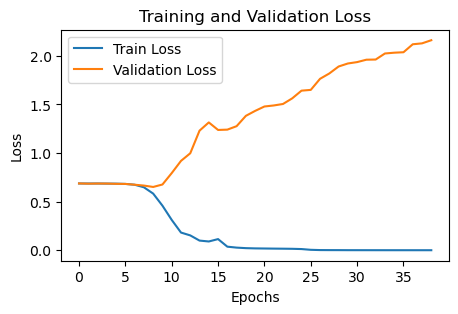

In [13]:
# BrainNetworkTransformer is FNC MODEL; FNC data is derived by its dataloader implicitly.
# Every model.prepare_dataloader() creates appropriate dataloader for its model

from ml4fmri.models import BNT
from sklearn.model_selection import train_test_split

# Split data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(DATA, LABELS, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.6, random_state=42)
input_size = DATA.shape[2]  # Feature size
n_classes = len(set(LABELS))  # Number of classes

# Print the shapes of the splits
print("Training data shape:", X_train.shape, y_train.shape)
print("Validation data shape:", X_val.shape, y_val.shape)
print("Test data shape:", X_test.shape, y_test.shape)

# prepare dataloaders for BNT. BNT is FNC model, so it will create FNC matrices from input time series.
train_dataloader = BNT.prepare_dataloader(X_train, y_train, batch_size=32)
val_dataloader = BNT.prepare_dataloader(X_val, y_val, batch_size=32)
test_dataloader = BNT.prepare_dataloader(X_test, y_test, batch_size=32)

# Train the BNT model
model = BNT(input_size=input_size, output_size=n_classes)
train_log, test_log, predictions_log = model.train_model(
    train_dataloader,
    val_dataloader,
    test_dataloader,
    epochs=100,
    )

# show test logs
print(f"Test logs:\n{test_log}\n")

# show training loss curves
import matplotlib.pyplot as plt

# Extract train and validation loss from train_log
train_loss = train_log['train_loss'].tolist()
val_loss = train_log['val_loss'].tolist()

# Plot the losses
plt.figure(figsize=(5, 3))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()
